In [1]:
# ==========================================
# CELL 1: Imports & Setup
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

# Set style for clear scientific plotting
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

# ==========================================
# CELL 2: Configuration
# ==========================================

# If you want to automatically find the latest csv in outputs:
csv_files = list(Path("outputs").glob("*.csv"))
if csv_files:
    # Get the most recent file
    latest_csv = max(csv_files, key=os.path.getctime)
    print(f"Automatically selected latest CSV: {latest_csv}")
    df = pd.read_csv(latest_csv)
else:
    raise FileNotFoundError("No CSV files found in the 'outputs' directory.")

# Filter out the very first step if it distorts the scale (optional)
# df = df[df['step'] > 0] 

print(f"Loaded {len(df)} rows.")
print("Columns:", df.columns.tolist())


Automatically selected latest CSV: outputs/step1_debug_s22342_pid1670195.csv
Loaded 67 rows.
Columns: ['step', 'loss_avg', 'v_curr_avg', 'td_target_avg', 'lr', 'ram_mb', 'agent_0_mae', 'agent_0_std_error', 'agent_0_max_error', 'agent_0_mean_bias', 'agent_0_std_bias', 'agent_0_rmse', 'agent_0_mean_pred', 'agent_0_mean_true', 'agent_0_mape', 'agent_0_pct_bias', 'agent_0_num_valid_pct_samples', 'agent_1_mae', 'agent_1_std_error', 'agent_1_max_error', 'agent_1_mean_bias', 'agent_1_std_bias', 'agent_1_rmse', 'agent_1_mean_pred', 'agent_1_mean_true', 'agent_1_mape', 'agent_1_pct_bias', 'agent_1_num_valid_pct_samples', 'agent_2_mae', 'agent_2_std_error', 'agent_2_max_error', 'agent_2_mean_bias', 'agent_2_std_bias', 'agent_2_rmse', 'agent_2_mean_pred', 'agent_2_mean_true', 'agent_2_mape', 'agent_2_pct_bias', 'agent_2_num_valid_pct_samples', 'agent_3_mae', 'agent_3_std_error', 'agent_3_max_error', 'agent_3_mean_bias', 'agent_3_std_bias', 'agent_3_rmse', 'agent_3_mean_pred', 'agent_3_mean_true',

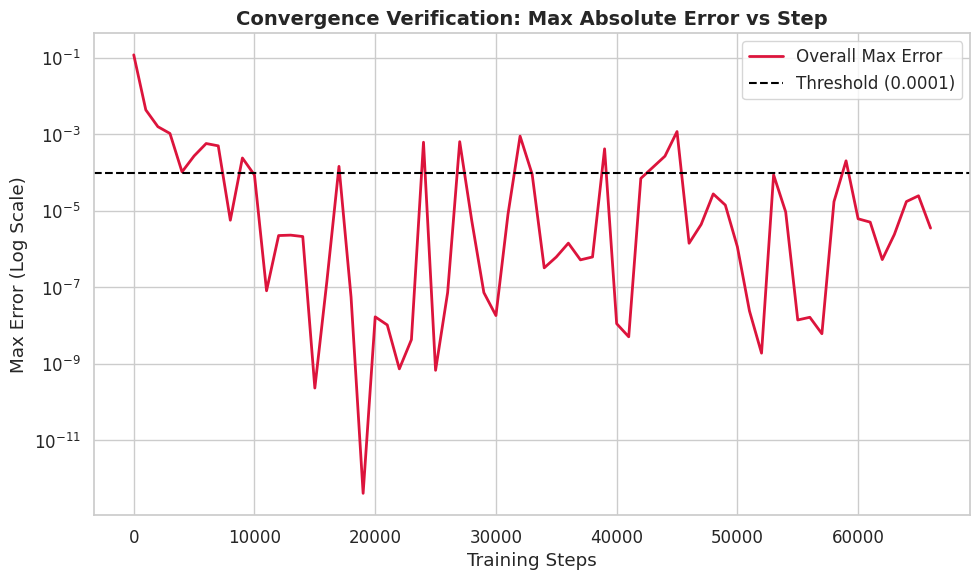


Status at Step 66000: PASSED
Final Max Error: 0.00000352


In [2]:

# ==========================================
# CELL 3: The "Bug Check" - Max Error Convergence
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Overall Max Error
sns.lineplot(data=df, x='step', y='overall_max_error', label='Overall Max Error', linewidth=2, color='crimson', ax=ax)

# Plot the Mathematical Guarantee Threshold
THRESHOLD = 0.0001
ax.axhline(y=THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Threshold ({THRESHOLD})')

# Aesthetics
ax.set_yscale('log')
ax.set_title("Convergence Verification: Max Absolute Error vs Step", fontsize=14, fontweight='bold')
ax.set_xlabel("Training Steps")
ax.set_ylabel("Max Error (Log Scale)")
ax.legend()

plt.tight_layout()
plt.show()

# Verification Logic
last_max_error = df['overall_max_error'].iloc[-1]
last_step = df['step'].iloc[-1]
status = "PASSED" if last_max_error < THRESHOLD else "FAILED/PENDING"
color = "green" if status == "PASSED" else "red"

print(f"\nStatus at Step {last_step}: {status}")
print(f"Final Max Error: {last_max_error:.8f}")
if status == "FAILED/PENDING":
    print(f"Distance to threshold: {last_max_error - THRESHOLD:.8f}")


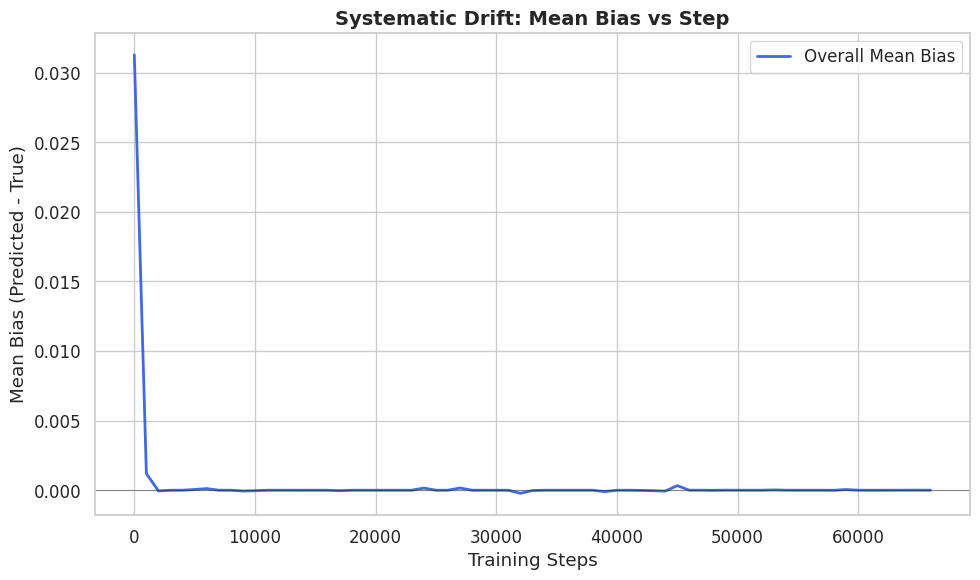

Final Mean Bias: 0.00000088


In [3]:

# ==========================================
# CELL 4: Mean Bias (Drift Check)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Overall Mean Bias
sns.lineplot(data=df, x='step', y='overall_mean_bias', label='Overall Mean Bias', linewidth=2, color='royalblue', ax=ax)

# Zero line
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Aesthetics
ax.set_title("Systematic Drift: Mean Bias vs Step", fontsize=14, fontweight='bold')
ax.set_xlabel("Training Steps")
ax.set_ylabel("Mean Bias (Predicted - True)")
ax.legend()

plt.tight_layout()
plt.show()

# Check for oscillation vs steady offset
print(f"Final Mean Bias: {df['overall_mean_bias'].iloc[-1]:.8f}")


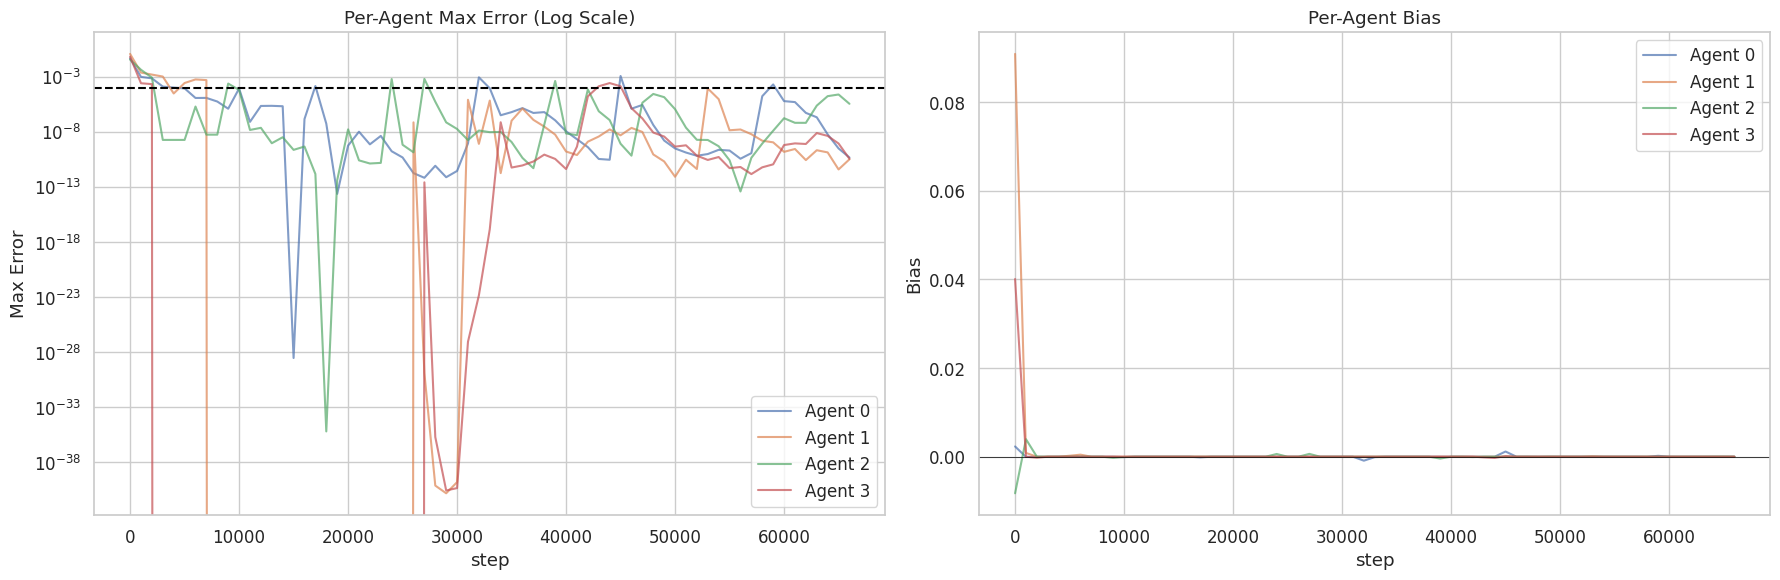

In [4]:

# ==========================================
# CELL 5: Per-Agent Breakdown (Are all agents healthy?)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Per-Agent Max Error
for i in range(4): # Assuming 4 agents
    col = f'agent_{i}_max_error'
    if col in df.columns:
        sns.lineplot(data=df, x='step', y=col, label=f'Agent {i}', ax=ax1, alpha=0.7)

ax1.set_yscale('log')
ax1.axhline(y=THRESHOLD, color='black', linestyle='--', label='Threshold')
ax1.set_title("Per-Agent Max Error (Log Scale)")
ax1.set_ylabel("Max Error")

# Subplot 2: Per-Agent Bias
for i in range(4):
    col = f'agent_{i}_mean_bias'
    if col in df.columns:
        sns.lineplot(data=df, x='step', y=col, label=f'Agent {i}', ax=ax2, alpha=0.7)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_title("Per-Agent Bias")
ax2.set_ylabel("Bias")

plt.tight_layout()
plt.show()
